<a href="https://colab.research.google.com/github/llatino/Portfolio/blob/main/Heart_Disease_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import io
import random
from google.colab import files

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as snsimport
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV

In [ ]:
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
heart_df = pd.read_csv(io.BytesIO(uploaded['train.csv']))

In [ ]:
clean_heart_df = heart_df.copy()
clean_heart_df['Heart Disease'] = clean_heart_df['Heart Disease'].map({'Presence': 0, 'Absence': 1})
clean_heart_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,0
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,1
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,1
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,1
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,0


## **Clarify Feature**

In [ ]:
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression' ]
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
selected_features = []
remaining_features = []

## **Descriptive Analysis**

In [ ]:
summary = []
def summarise(feature):
  avg = round(np.mean(clean_heart_df[feature]).item(),2)
  sd = round(np.std(clean_heart_df[feature]),2)
  q1 = np.quantile(clean_heart_df[feature], [0.25]).item()
  q2 = np.quantile(clean_heart_df[feature], [0.5]).item()
  q3 = np.quantile(clean_heart_df[feature], [0.75]).item()
  mx = np.max(clean_heart_df[feature])
  mm = np.min(clean_heart_df[feature])
  return feature, avg, sd, q1, q2, q3, mx, mm

In [ ]:
for feature in numerical_features:
  val = summarise(feature)
  summary.append(val)

In [ ]:
columns = ['Feature', 'Mean', 'Std', '25%', '50%', '75%', 'Max', 'Min']
df_summary = pd.DataFrame(summary, columns=columns)
print(df_summary)

         Feature    Mean    Std    25%    50%    75%    Max    Min
0            Age   54.14   8.26   48.0   54.0   60.0   77.0   29.0
1             BP  130.50  14.98  120.0  130.0  140.0  200.0   94.0
2    Cholesterol  245.01  33.68  223.0  243.0  269.0  564.0  126.0
3         Max HR  152.82  19.11  142.0  157.0  166.0  202.0   71.0
4  ST depression    0.72   0.95    0.0    0.1    1.4    6.2    0.0


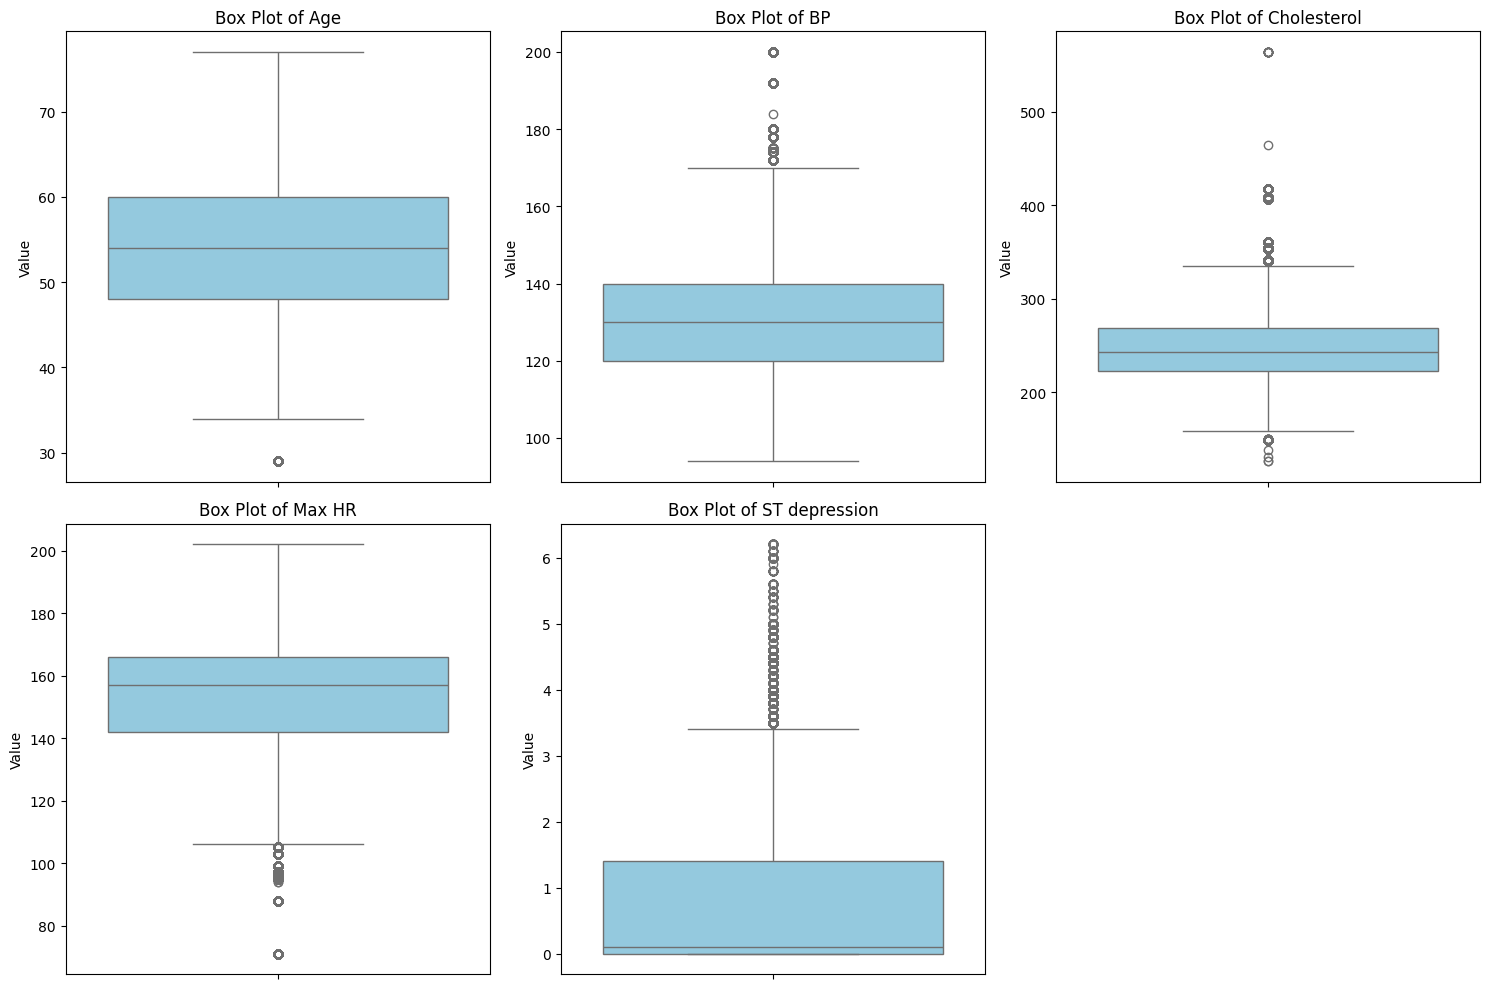

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # สร้าง grid 2 แถว 3 คอลัมน์
    sns.boxplot(y=clean_heart_df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # กรองเอาเฉพาะข้อมูลที่อยู่ในช่วงที่กำหนด
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# ตัวอย่างการใช้งานกับคอลัมน์ที่พบ Outliers เยอะๆ
for i in numerical_features:
  mean_before = clean_heart_df[i].mean()
  std_before = clean_heart_df[i].std()

  clean_df_no_outliers = remove_outliers(clean_heart_df, i)

  mean_after = clean_df_no_outliers[i].mean()
  std_after = clean_df_no_outliers[i].std()
  print(f"Mean Before: {mean_before:.2f}, Mean After: {mean_after:.2f}")
  print(f"Std Before: {std_before:.2f}, Std After: {std_after:.2f}")

Mean Before: 54.14, Mean After: 54.18
Std Before: 8.26, Std After: 8.20
Mean Before: 130.50, Mean After: 129.77
Std Before: 14.98, Std After: 13.78
Mean Before: 245.01, Mean After: 244.95
Std Before: 33.68, Std After: 33.05
Mean Before: 152.82, Mean After: 154.02
Std Before: 19.11, Std After: 17.58
Mean Before: 0.72, Mean After: 0.66
Std Before: 0.95, Std After: 0.86


In [ ]:
n_bf_out = len(clean_heart_df)
n_af_out = len(clean_df_no_outliers)

print(n_bf_out)
print(n_af_out)

630000
620029


Sex
0    179717
1    450283
Name: count, dtype: int64
None


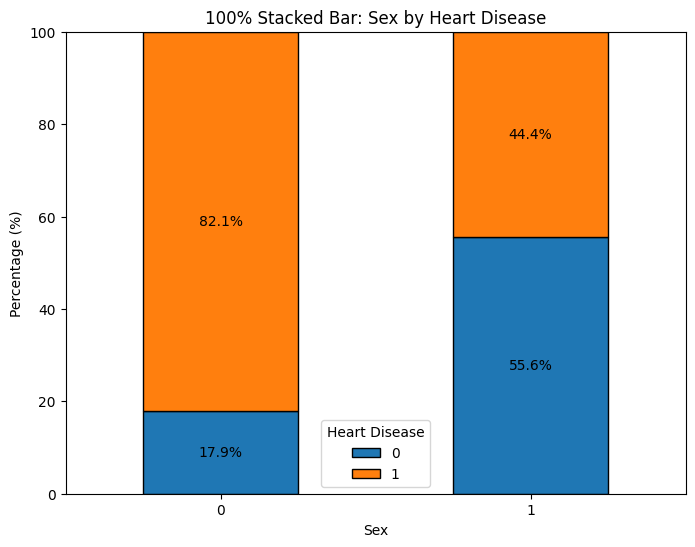

Chest pain type
1     28602
2     74941
3    197278
4    329179
Name: count, dtype: int64
None


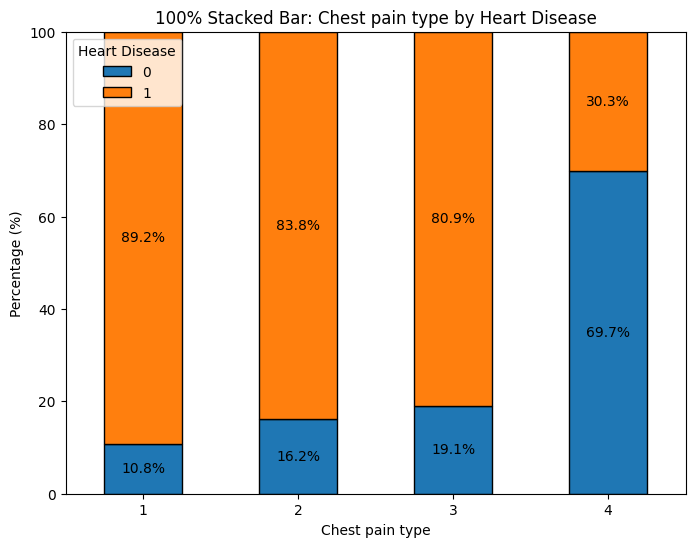

FBS over 120
0    579608
1     50392
Name: count, dtype: int64
None


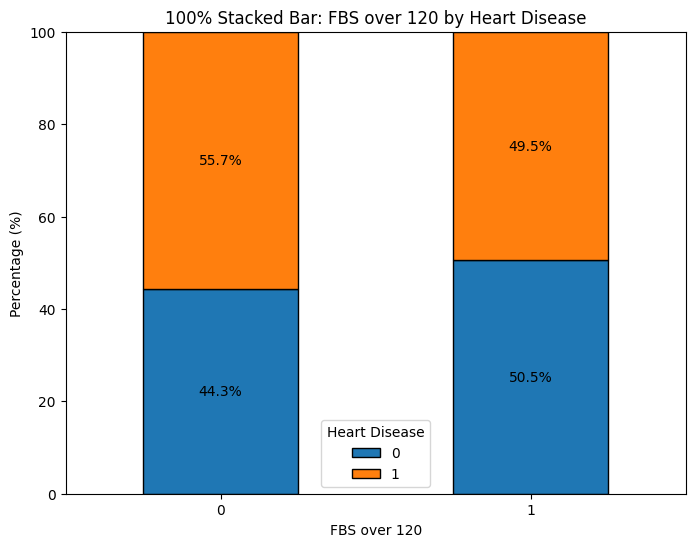

EKG results
0    320116
1      1322
2    308562
Name: count, dtype: int64
None


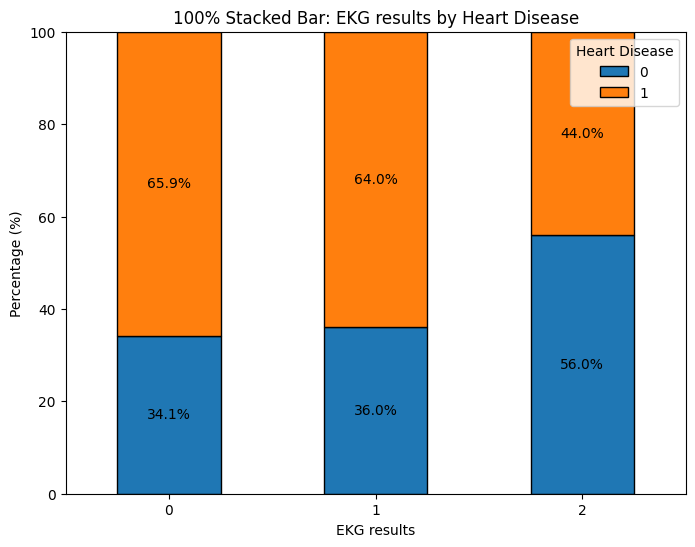

Exercise angina
0    457553
1    172447
Name: count, dtype: int64
None


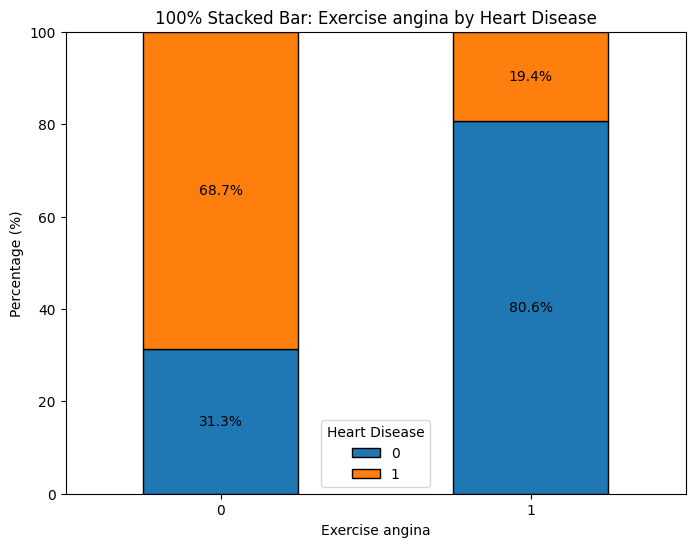

Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64
None


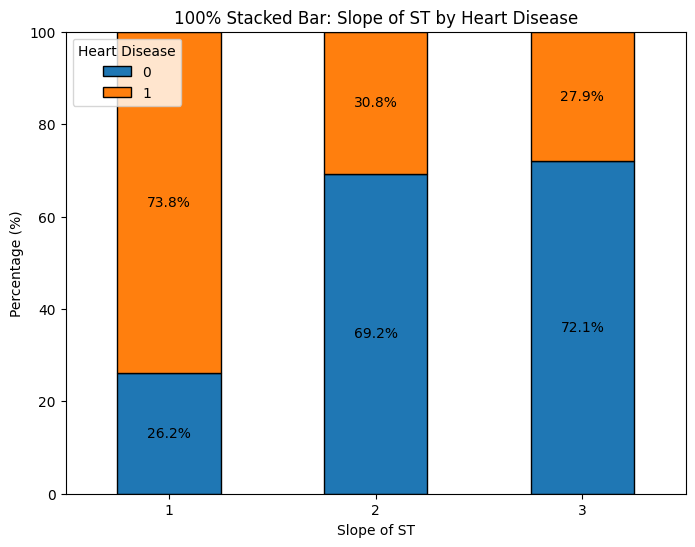

Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64
None


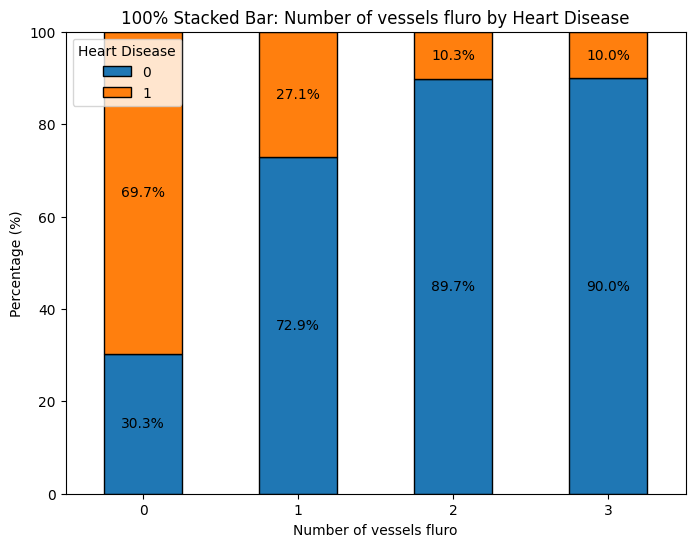

Thallium
3    372286
6     10966
7    246748
Name: count, dtype: int64
None


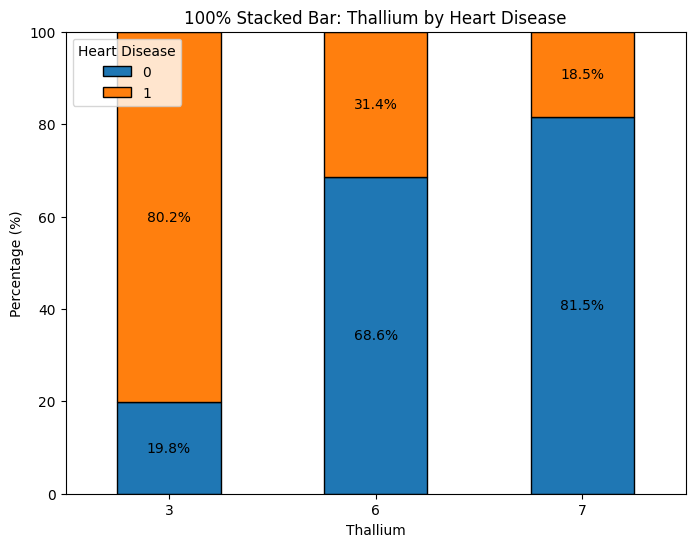

In [ ]:
def counts(feature):
  count = clean_heart_df[feature].value_counts().sort_index()
  print(count)

for feature in categorical_features:
  count = counts(feature)
  print(count)
  count_data = clean_heart_df[feature].value_counts().sort_index()

  data = pd.crosstab(clean_heart_df[feature], clean_heart_df['Heart Disease'])
  data_percentage = data.div(data.sum(1), axis=0) * 100
  ax = data_percentage.plot(kind='bar', stacked=True, figsize=(8, 6), edgecolor='black')

  plt.title(f'100% Stacked Bar: {feature} by {'Heart Disease'}')
  plt.xlabel(feature)
  plt.ylabel('Percentage (%)')
  plt.xticks(rotation=0)
  plt.ylim(0, 100) # บังคับให้แกน Y เต็มที่ 100

  for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='center')

  plt.show()

Heart Disease
0    282454
1    347546
Name: count, dtype: int64
None


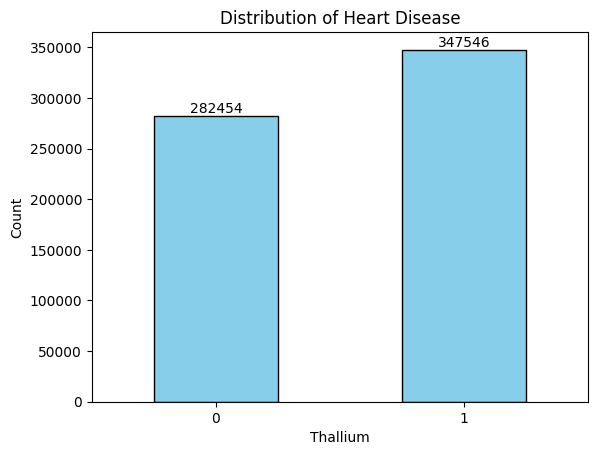

In [ ]:
disease = counts('Heart Disease')
print(disease)


count_data = clean_heart_df['Heart Disease'].value_counts().sort_index()

count_data.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title(f'Distribution of {'Heart Disease'}')
plt.xlabel(feature)
plt.ylabel('Count')
plt.xticks(rotation=0)

for i, v in enumerate(count_data):
      plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

## **Feature selection**

### **T-test**

In [ ]:
def t_test(num_feature):
  t_value = 0
  p_value = 0

  s0 = clean_df_no_outliers[clean_df_no_outliers['Heart Disease'] == 0]
  s1 = clean_df_no_outliers[clean_df_no_outliers['Heart Disease'] == 1]

  t_stat, p_val = stats.ttest_ind(s0[num_feature],s1[num_feature])

  t_value = t_stat
  p_value = p_val

  print(f"Calculated t-test of {num_feature}")
  print(f"t-statistic: {t_value:.2f}")
  print(f"p-value: {p_value:.5f}")

for num in numerical_features:
 t_test(num)

Calculated t-test of Age
t-statistic: 170.37
p-value: 0.00000
Calculated t-test of BP
t-statistic: -4.18
p-value: 0.00003
Calculated t-test of Cholesterol
t-statistic: 64.96
p-value: 0.00000
Calculated t-test of Max HR
t-statistic: -385.83
p-value: 0.00000
Calculated t-test of ST depression
t-statistic: 370.73
p-value: 0.00000


In [ ]:
def cohen_d(df, factor_col, target_col):
    # แยกกลุ่มข้อมูล (0 = Absence, 1 = Presence)
    group1 = df[df[target_col] == 0][factor_col]
    group2 = df[df[target_col] == 1][factor_col]

    # คำนวณค่าเฉลี่ยและจำนวนข้อมูล
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # คำนวณ Pooled Standard Deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    # คำนวณ Cohen's d
    d = (group1.mean() - group2.mean()) / pooled_std
    return abs(d)

# ตัวอย่างการใช้งานกับตัวแปรที่คุณสนใจ
# สมมติใช้ 'Max HR' เปรียบเทียบระหว่างกลุ่ม Heart Disease
for f in numerical_features:
  d_val = cohen_d(clean_heart_df, f, 'Heart Disease')
  if d_val > 0.9:
    selected_features.append(f)
  print(f"Cohen's d ของ {f}: {d_val:.4f}")

Cohen's d ของ Age: 0.4364
Cohen's d ของ BP: 0.0104
Cohen's d ของ Cholesterol: 0.1670
Cohen's d ของ Max HR: 0.9880
Cohen's d ของ ST depression: 0.9594


### **Shi2**

In [ ]:
def chi2(cat_feature):
  contingency_table = pd.crosstab(clean_df_no_outliers[cat_feature], clean_df_no_outliers['Heart Disease'])

  chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

  c = chi2
  p = p_val

  print(f"Calculated Chi-Square of {cat_feature}")
  print(f"Chi-square: {c:.2f}")
  print(f"p-value: {p:.5f}")

for cat in categorical_features:
  chi2(cat)



Calculated Chi-Square of Sex
Chi-square: 71808.44
p-value: 0.00000
Calculated Chi-Square of Chest pain type
Chi-square: 169685.40
p-value: 0.00000
Calculated Chi-Square of FBS over 120
Chi-square: 676.03
p-value: 0.00000
Calculated Chi-Square of EKG results
Chi-square: 29253.11
p-value: 0.00000
Calculated Chi-Square of Exercise angina
Chi-square: 120054.03
p-value: 0.00000
Calculated Chi-Square of Slope of ST
Chi-square: 111492.70
p-value: 0.00000
Calculated Chi-Square of Number of vessels fluro
Chi-square: 131748.83
p-value: 0.00000
Calculated Chi-Square of Thallium
Chi-square: 226563.93
p-value: 0.00000


In [ ]:
def cramers_v(x, y):
    # สร้าง contingency table
    confusion_matrix = pd.crosstab(x, y)

    # คำนวณ Chi-square statistic
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # คำนวณค่า Bias correction (เพื่อให้แม่นยำขึ้นสำหรับข้อมูลขนาดใหญ่)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# ตัวอย่างการใช้งานกับ EKG และ Heart Disease
for u in categorical_features:
  v_score = cramers_v(clean_heart_df[u], clean_heart_df['Heart Disease'])
  if v_score > 0.4:
    selected_features.append(u)
  print(f"Cramér's V ของ {u}: {v_score:.4f}")

Cramér's V ของ Sex: 0.3424
Cramér's V ของ Chest pain type: 0.5252
Cramér's V ของ FBS over 120: 0.0335
Cramér's V ของ EKG results: 0.2191
Cramér's V ของ Exercise angina: 0.4419
Cramér's V ของ Slope of ST: 0.4298
Cramér's V ของ Number of vessels fluro: 0.4632
Cramér's V ของ Thallium: 0.6058


## **Train model**

In [ ]:
X = clean_df_no_outliers[selected_features]
y = clean_df_no_outliers['Heart Disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Random Forest method**

In [ ]:
rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_split=15,
        random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nDetailed Report:\n", classification_report(y_test, y_pred_rf))

Model Accuracy: 87.79%

Detailed Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.86     54641
           1       0.88      0.90      0.89     69365

    accuracy                           0.88    124006
   macro avg       0.88      0.87      0.88    124006
weighted avg       0.88      0.88      0.88    124006



## **Prediction**




In [ ]:
uploaded = files.upload()

Saving test.csv to test.csv


In [ ]:
submission_df = pd.read_csv(io.BytesIO(uploaded['test.csv']))

In [ ]:
X_submission = submission_df[selected_features]

p_heart = rf_model.predict(X_submission)

submission_df['Heart Disease'] = p_heart

In [ ]:
submission_df.to_csv('submission_rf.csv', index=False)

In [ ]:
files.download('submission_rf.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>